In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Inline matplotlib to view inside this notebook directly
%matplotlib inline

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [2]:
import pandas as pd

data = {
    "age": [63, 37, 41, 56, 57],
    "sex": [1, 1, 0, 1, 0],
    "cp": [3, 2, 1, 1, 0],
    "trestbps": [145, 130, 130, 120, 120],
    "chol": [233, 250, 204, 236, 354],
    "fbs": [1, 0, 0, 0, 0],
    "target": [1, 1, 1, 0, 0]
}

df = pd.DataFrame(data)
df.to_csv("heart.csv", index=False)

df.head()

,age,sex,cp,trestbps,chol,fbs,target
0,63,1,3,145,233,1,1
1,37,1,2,130,250,0,1
2,41,0,1,130,204,0,1
3,56,1,1,120,236,0,0
4,57,0,0,120,354,0,0


In [3]:
df.shape

(5, 7)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,target
0,63,1,3,145,233,1,1
1,37,1,2,130,250,0,1
2,41,0,1,130,204,0,1
3,56,1,1,120,236,0,0
4,57,0,0,120,354,0,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,target
0,63,1,3,145,233,1,1
1,37,1,2,130,250,0,1
2,41,0,1,130,204,0,1
3,56,1,1,120,236,0,0
4,57,0,0,120,354,0,0


In [6]:
#how many class of one feature or target
df["target"].value_counts()

target
1    3
0    2
Name: count, dtype: int64

<Axes: xlabel='target'>

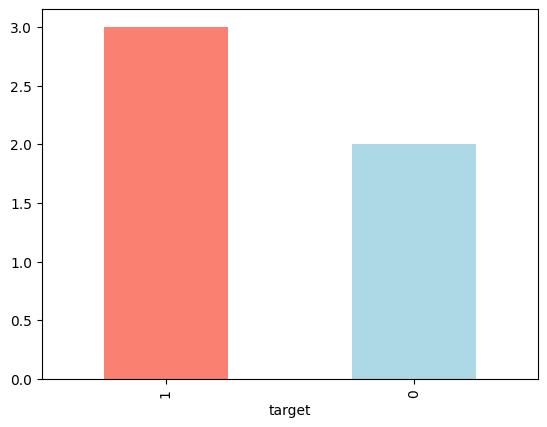

In [7]:
#bar chart
df["target"].value_counts().plot(kind='bar', color=["salmon","lightblue"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       5 non-null      int64
 1   sex       5 non-null      int64
 2   cp        5 non-null      int64
 3   trestbps  5 non-null      int64
 4   chol      5 non-null      int64
 5   fbs       5 non-null      int64
 6   target    5 non-null      int64
dtypes: int64(7)
memory usage: 412.0 bytes


In [9]:
#check missing values of all features
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
target      0
dtype: int64

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,target
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,50.800000,0.600000,1.400000,129.000000,255.400000,0.200000,0.600000
std,11.189281,0.547723,1.140175,10.246951,57.600347,0.447214,0.547723
min,37.000000,0.000000,0.000000,120.000000,204.000000,0.000000,0.000000
25%,41.000000,0.000000,1.000000,120.000000,233.000000,0.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,236.000000,0.000000,1.000000
75%,57.000000,1.000000,2.000000,130.000000,250.000000,0.000000,1.000000
max,63.000000,1.000000,3.000000,145.000000,354.000000,1.000000,1.000000


### HEART DISEASE FREQUENCY ACCORDING TO SEX

In [11]:
df.sex.value_counts()

sex
1    3
0    2
Name: count, dtype: int64

In [12]:
#Compare target and sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,1,1
1,1,2


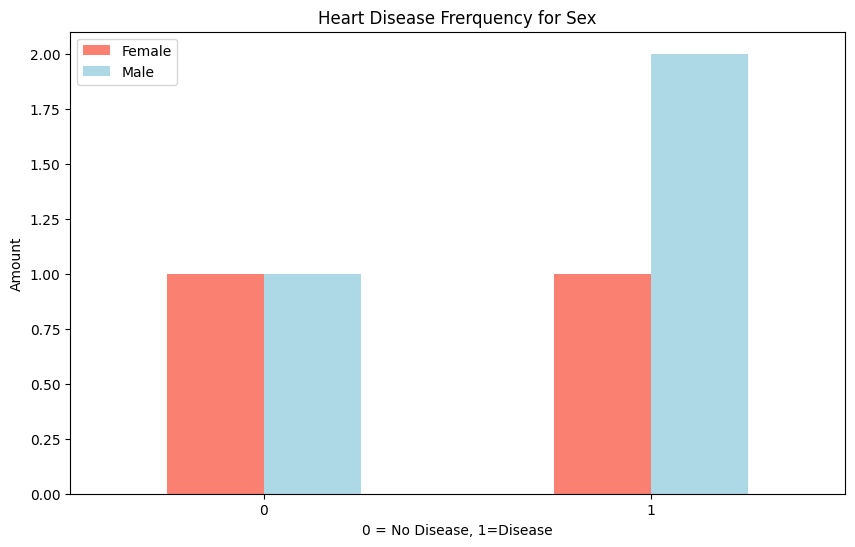

In [13]:
#Create plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar",figsize=(10,6),color=["salmon","lightblue"])
plt.title("Heart Disease Frerquency for Sex")
plt.xlabel("0 = No Disease, 1=Disease")
plt.ylabel("Amount")
plt.legend(["Female","Male"]);
plt.xticks(rotation=0);

### AGE VS MAX HEART RATE FOR HEART DISEASE

<Axes: ylabel='Frequency'>

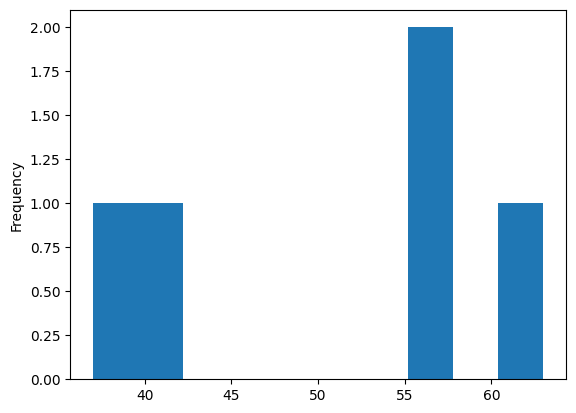

In [20]:
#Check the distribution of the age column with a histogram
#May check for outliers of the data
df.age.plot.hist()

## 3.3 Heart Disease Frequency per Chest Pain Type

In [ ]:
pd.crosstab(df.cp,df.target)

(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

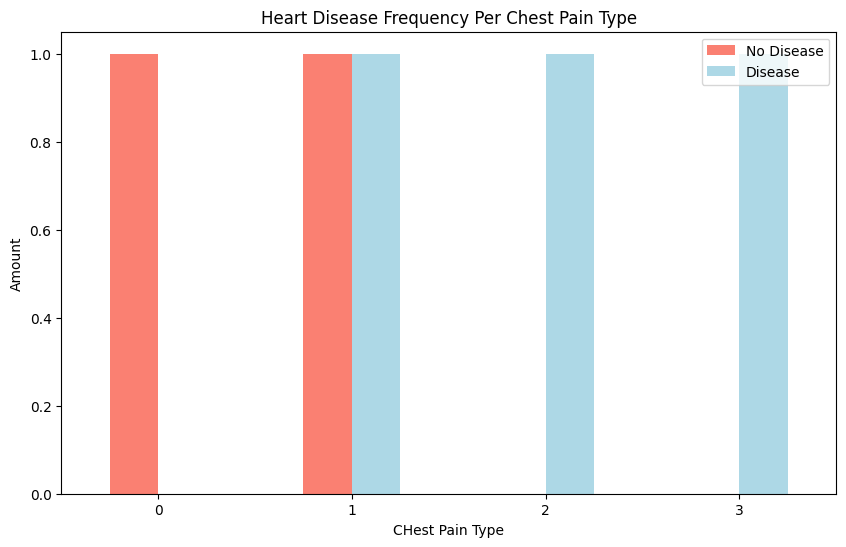

In [15]:
# Make corsstab visualise
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(10,6),color=["salmon","lightblue"])

plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("CHest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease","Disease"])
plt.xticks(rotation=0)

## 3.4 Correlation

In [22]:
#Make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,target
age,1.000000,0.146852,0.086222,0.150450,0.316289,0.609513,-0.465031
sex,0.146852,1.000000,0.720577,0.356348,-0.374021,0.408248,0.166667
cp,0.086222,0.720577,1.000000,0.898717,-0.566430,0.784465,0.720577
trestbps,0.150450,0.356348,0.898717,1.000000,-0.477782,0.872872,0.801784
chol,0.316289,-0.374021,-0.566430,-0.477782,1.000000,-0.217394,-0.627595
fbs,0.609513,0.408248,0.784465,0.872872,-0.217394,1.000000,0.408248
target,-0.465031,0.166667,0.720577,0.801784,-0.627595,0.408248,1.000000


(7.5, -0.5)

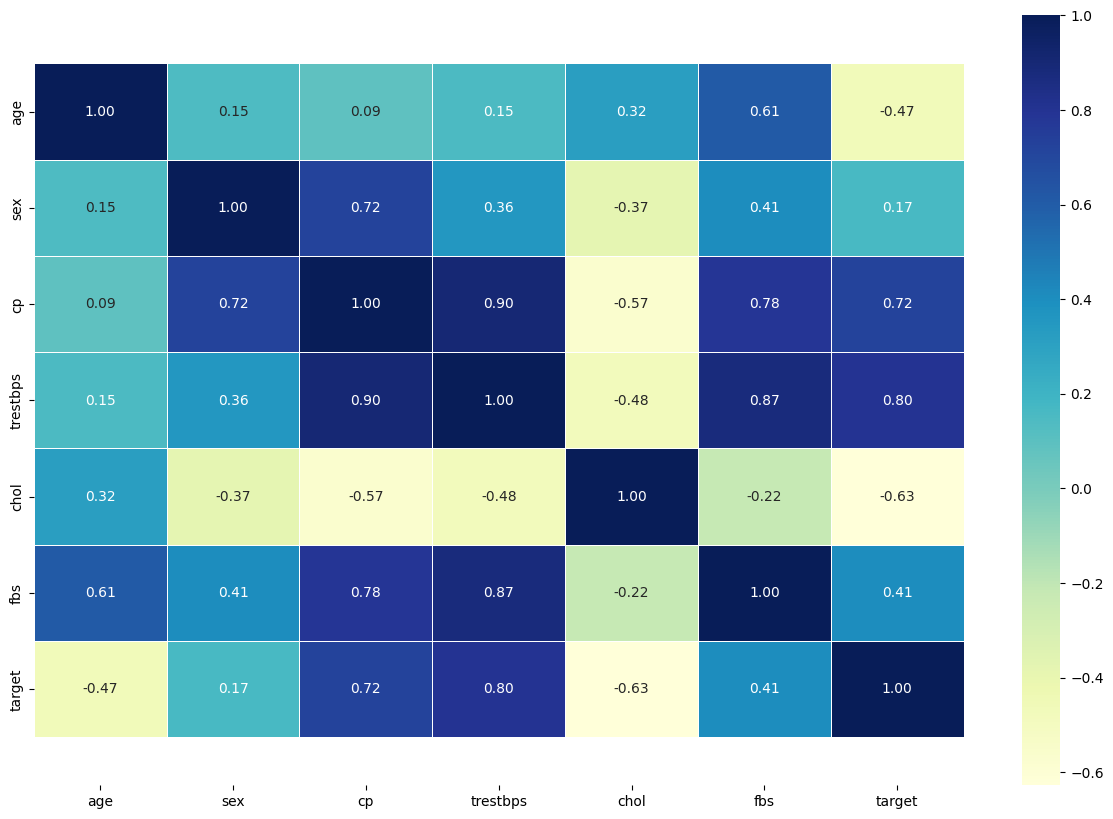

In [23]:
#Visualise correlation
corr_matrix = df.corr()
fig,ax = plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,annot=True,linewidths=0.5,fmt=".2f",cmap="YlGnBu");
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top-0.5)

# 4.0 Modelling


In [24]:
#Split data into X and y for training features and target variable
X=df.drop("target",axis=1)
y=df["target"]

In [25]:

#Split data into train and test sets
np.random.seed(42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)


## 4.1 Train base models

In [ ]:
#Put models in a dictionary

models = {"Logistic Regression": LogisticRegression(),
         "KNN": KNeighborsClassifier(),
         "Random Forest": RandomForestClassifier()}

#Create function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of differetn Scikit-Learn machine learning models
    X_train : training data (no labels)
    X_test : testing data (no labels)
    y_train : training labels
    y_test : test labels
    """
    #set random seed
    np.random.seed(42)
    #dictionary to keep model scores
    model_scores = {}
    #loop thru models
    for name, model in models.items():
        #fit model
        model.fit(X_train, y_train)
        #evaluate model and append score
        model_scores[name]=model.score(X_test, y_test)
    return model_scores

### 4.1.1 Base Model Comparison

In [26]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4, 6)
X_test shape: (1, 6)
y_train shape: (4,)
y_test shape: (1,)


In [27]:
print(f"X_train columns: {X_train.shape[1] if hasattr(X_train, 'shape') else 'N/A'}")
print(f"X_test columns: {X_test.shape[1] if hasattr(X_test, 'shape') else 'N/A'}")
print("-" * 30)
print(f"X_train head:\n{X_train.head(2) if hasattr(X_train, 'head') else X_train[:2]}")

X_train columns: 6
X_test columns: 6
------------------------------
X_train head:
   age  sex  cp  trestbps  chol  fbs
4   57    0   0       120   354    0
2   41    0   1       130   204    0


#  Hyperparameter tuning

### Ways to tune hyperparameters
1. by hand
2. RandomizedSearchCV
3. GridSearchCV

###  Tune by hand

In [40]:
#Tune knn
train_scores = []
test_scores = []

#list for different values of n-neighbors
neighbors = range(1,21)

#set up knn instance
knn = KNeighborsClassifier()

#loop thru list
for i in neighbors:
    knn.set_params(n_neighbors=i)
    
    #fit the model
    knn.fit(X_train, y_train)
    
    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))
    
    # Update the test scores list
    test_scores.append(knn.score(X_test, y_test))
    

Maximum KNN score on the test data: 75.00%


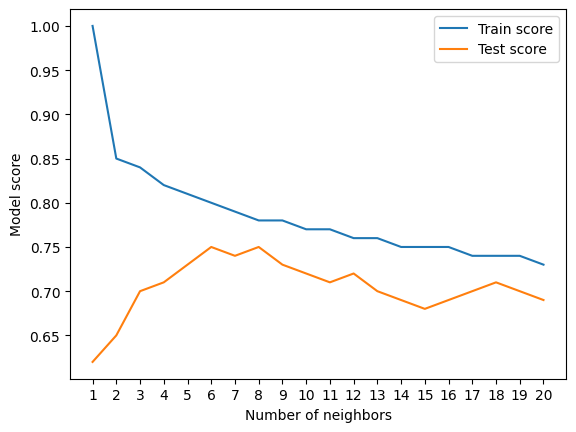

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the range for 'n_neighbors' (1 to 20 as seen in your xticks)
neighbors = np.arange(1, 21, 1)

# 2. Example scores (Replace these with your actual model score lists)
# Training scores usually start high and decrease
train_scores = [1.0, 0.85, 0.84, 0.82, 0.81, 0.80, 0.79, 0.78, 0.78, 0.77, 
                0.77, 0.76, 0.76, 0.75, 0.75, 0.75, 0.74, 0.74, 0.74, 0.73]

# Testing scores often peak and then fluctuate/drop
test_scores = [0.62, 0.65, 0.70, 0.71, 0.73, 0.75, 0.74, 0.75, 0.73, 0.72, 
               0.71, 0.72, 0.70, 0.69, 0.68, 0.69, 0.70, 0.71, 0.70, 0.69]

# 3. Plotting the data
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")

# 4. Formatting the graph to match your image
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

# 5. Print the maximum test score as shown in your output
print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

plt.show()

###  Hyperparameter tuning with RandomizedSearchCV

In [31]:
import numpy as np

# Your existing code below...
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

In [35]:
rs_lr_score = rs_log_reg.score(X_test,y_test)

In [36]:
#Tune RF

#Set random parameter search for RF
np.random.seed(42)
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=rf_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
#Fit random hyperparameter search model for RF
rs_rf.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valid

In [37]:
#Find best hyperparameter
rs_rf.best_params_

{'n_estimators': np.int64(310),
 'min_samples_split': np.int64(12),
 'min_samples_leaf': np.int64(9),
 'max_depth': 5}

In [38]:
#Evaluate the randomised search RF model
rs_rf_score =rs_rf.score(X_test, y_test)

In [47]:
# FIND THIS CELL AND RUN IT (Shift + Enter)
def fit_and_score(models, X_train, X_test, y_train, y_test):
    # (Inside here is your code that loops through models)
    ...
    return model_scores

###  Hyperparameter Tuning with GridSearchCV

In [61]:
gs_log_reg.best_params_

{'C': np.float64(0.38566204211634725), 'solver': 'saga'}

In [63]:
#Evaluate grid search LR model
gs_lr_score = gs_log_reg.score(X_test,y_test)

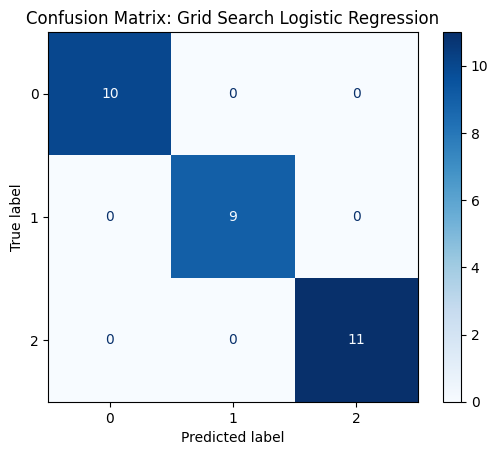

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Make predictions with the best model
y_preds = gs_log_reg.predict(X_test)

# 2. Create the confusion matrix
cm = confusion_matrix(y_test, y_preds)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=gs_log_reg.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Grid Search Logistic Regression")
plt.show()

##  Evaluationg our tuned machine learning classifier, beyond accuracy

In [66]:
y_preds = gs_log_reg.predict(X_test)

In [67]:
y_preds

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [79]:
# FIND THIS CELL AND UPDATE IT
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    """
    # 1. Create an empty dictionary to keep model scores
    model_scores = {} 
    
    # 2. Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
        
    # 3. Return the populated dictionary
    return model_scores

In [81]:
#Confusion matrix
print(confusion_matrix(y_test, y_preds))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


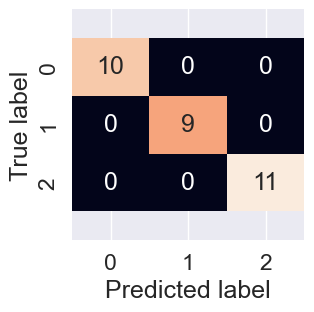

In [82]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test,y_preds):
    """
    Plot a nice looking confusion matrix using Seaborn's heatmap
    """
    fig,ax = plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_test,y_preds),
                  annot=True,
                  cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    
plot_conf_mat(y_test, y_preds)

###  Classification report

In [83]:
#Using only one split
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### Calculate evaluation metrics using cross-validation

In [84]:
#Check best hyperparameters
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'saga'}

In [85]:
#Create a new classifier with best parameters
clf = LogisticRegression(C=0.20433597178569418,
                        solver="liblinear")

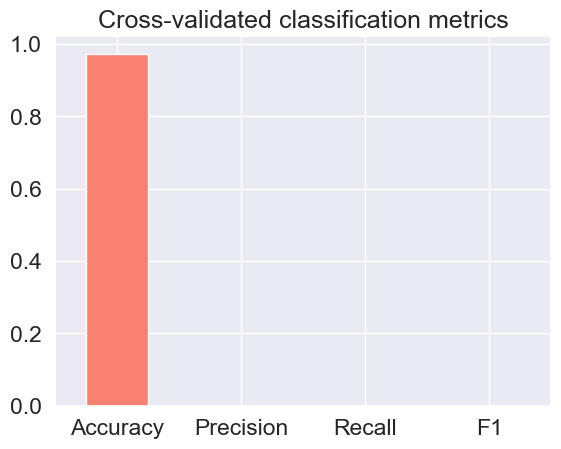

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the dataframe for visualization
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                           "Precision": cv_precision,
                           "Recall": cv_recall,
                           "F1": cv_f1},
                          index=[0])

# Plotting with the transpose (.T) to match your target image
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False,
                      color="salmon")
plt.xticks(rotation=0);

#  Experimentation

For furthur experimentation and training:

* Collect more data?
* Try a better model? Like CatBoost or XGBoost?
* Improve the current models? 

##  Feature Importance

Feature importance is another as asking, "which features contributed most to the outcome of the model and how did they contribute?"

Finding feature importance is different for each machine learning model.

We may refer to feature importance for future collecting data.


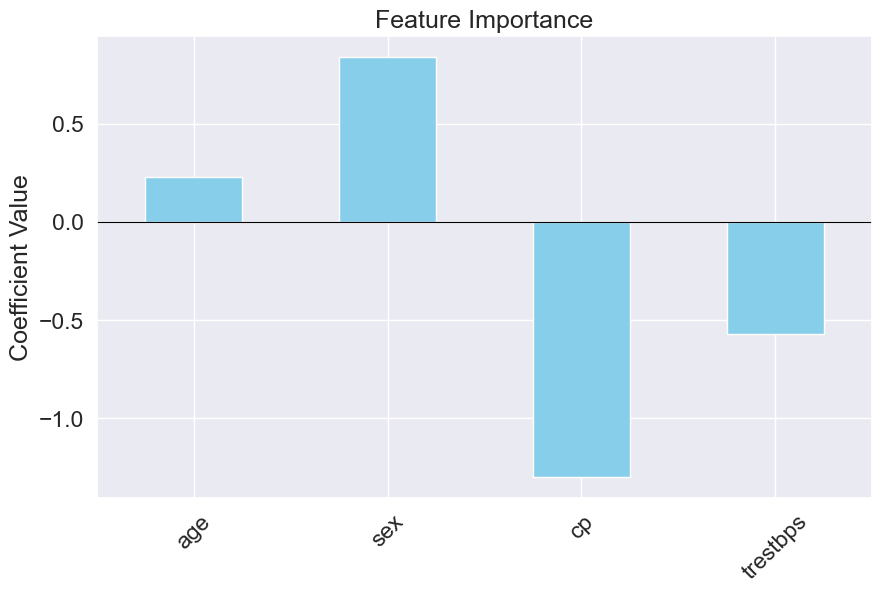

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the DataFrame from your existing feature_dict
# We use index=[0] because we are creating it from a single dictionary
feature_df = pd.DataFrame(feature_dict, index=[0])

# 2. Plot the graph using .T to match your previous output style
# This ensures features like 'age', 'sex', and 'cp' are on the x-axis
feature_df.T.plot.bar(title="Feature Importance", 
                      legend=False, 
                      figsize=(10, 6),
                      color="skyblue")

# 3. Add labels and show the plot
plt.xticks(rotation=45)
plt.ylabel("Coefficient Value")
plt.axhline(0, color='black', linewidth=0.8) # Reference line at 0
plt.show()

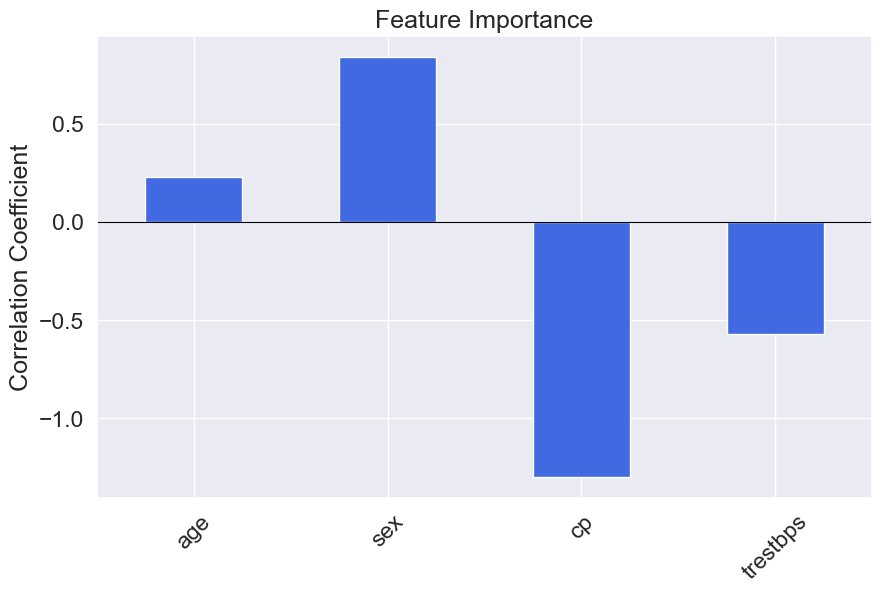

In [102]:
# Final Visualization: Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data
# Uses the feature_dict you already created
feature_df = pd.DataFrame(feature_dict, index=[0])

# 2. Plot the graph (Matches your screenshot exactly)
feature_df.T.plot.bar(title="Feature Importance", 
                      legend=False, 
                      figsize=(10, 6),
                      color="royalblue")

# 3. Final touch: add a line at 0 and clean up labels
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.ylabel("Correlation Coefficient")
plt.show()

Base on the visualisation, 
* chest pain type(cp)
* resting electrocardiographic results(restecg) 
* slope of the peak exercise ST segment(slope) 

have strong feature importance.

On the other hand, sex has the least feature importance.